In [84]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Literal
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv


In [85]:
load_dotenv()

True

In [86]:
model = ChatOpenAI()

In [87]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="Provides the type of issue the user is facing.")
    tone: Literal["angry", "frustrated", "disappointment", "calm"] = Field(description="The emotional tone expressed by the user.")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

In [88]:
class Response(BaseModel):
    sentiment: Literal['positive', 'negative'] = None
    input_statement: str
    diagnoses: DiagnosisSchema = None
    response: str = None

In [89]:
class Sentiment(BaseModel):
    sentiment: str = None

In [90]:
sentiment_model = model.with_structured_output(Sentiment)
diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [91]:
def find_sentiment(state: Response):
    sentiment = sentiment_model.invoke(state.input_statement)
    return {"sentiment": sentiment.sentiment}


In [92]:
def run_diagnosis(state: Response):
    prompt = f"Diagnose the negative review-> {state.input_statement}. Return the issue type, tone and urgency"
    diagnosis = diagnosis_model.invoke(prompt)
    return {"diagnoses": diagnosis}


In [93]:
def respond_positive_email(state: Response):
    prompt = f"Write a positive thank you note to the user for the email {state.input_statement}"
    response = model.invoke(prompt).content
    return {"response" : response}


In [94]:
def respond_negative_email(state: Response) -> Response:
    prompt = f"Write a supportive note to the user for the email {state.input_statement}. The user had a diagnosis with issue of type {state.diagnoses.issue_type} and the tone sounded  {state.diagnoses.tone}"
    response = model.invoke(prompt).content
    return {"response" : response}

In [100]:
def check_email_type(state: Response) -> Literal["respond_positive_email", "run_diagnosis"]:
    if state.sentiment == "positive":
        return "respond_positive_email"
    return "run_diagnosis"


In [96]:
prompt = """Subject: Resignation

Hello John,

I am sure you already know, as I discussed with Julie, but I am resigning from Google team effective today.

I appreciate the opportunity, but I believe this particular position is best suited for someone whose dedicated specialty is not in content marketing and SEO. 

I have no doubt in my mind that Google will be successful in the future. You have beautiful products and a wonderful, hardworking team in place. You guys are idiots. 

Thank you,
Caileen Kehayas"""

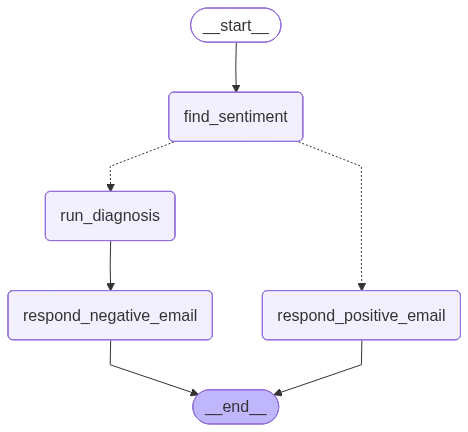

In [107]:
graph = StateGraph(Response)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("respond_positive_email", respond_positive_email)
graph.add_node("respond_negative_email", respond_negative_email)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_email_type)
graph.add_edge("run_diagnosis", "respond_negative_email")
graph.add_edge("respond_positive_email", END)
graph.add_edge("respond_negative_email", END)

workflow = graph.compile()
workflow

In [108]:
workflow.invoke({"input_statement": prompt})


{'sentiment': 'negative',
 'input_statement': 'Subject: Resignation\n\nHello John,\n\nI am sure you already know, as I discussed with Julie, but I am resigning from Google team effective today.\n\nI appreciate the opportunity, but I believe this particular position is best suited for someone whose dedicated specialty is not in content marketing and SEO. \n\nI have no doubt in my mind that Google will be successful in the future. You have beautiful products and a wonderful, hardworking team in place. You guys are idiots. \n\nThank you,\nCaileen Kehayas',
 'diagnoses': DiagnosisSchema(issue_type='UX', tone='frustrated', urgency='medium'),
 'response': "Hello Caileen,\n\nI'm sorry to hear that you have decided to resign from the Google team, but I understand your reasons for doing so. It's important to recognize when a position may not be the best fit for your skills and expertise.\n\nI want to thank you for your hard work and dedication during your time with us. Your contributions to the